# NHANES Data Analysis & Obesity Prediction
## 03 — EDA Part 2: Visualization

## This notebook explores the distribution of key demographic and clinical variables in the NHANES dataset using univariate, bivariate, and categorical visualizations. These plots help reveal patterns in age, income, body measurements, and obesity across different population groups.

## 1. Load the Dataset

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
filepath = r"C:\Users\Roza Aissaoui\Desktop\Dashboard project\Code\nhanes_obesity_analysis\clean_merged_data.csv"
df = pd.read_csv(filepath)

## 2. Univariate Visualizations

### 2.1 Continuous Variables

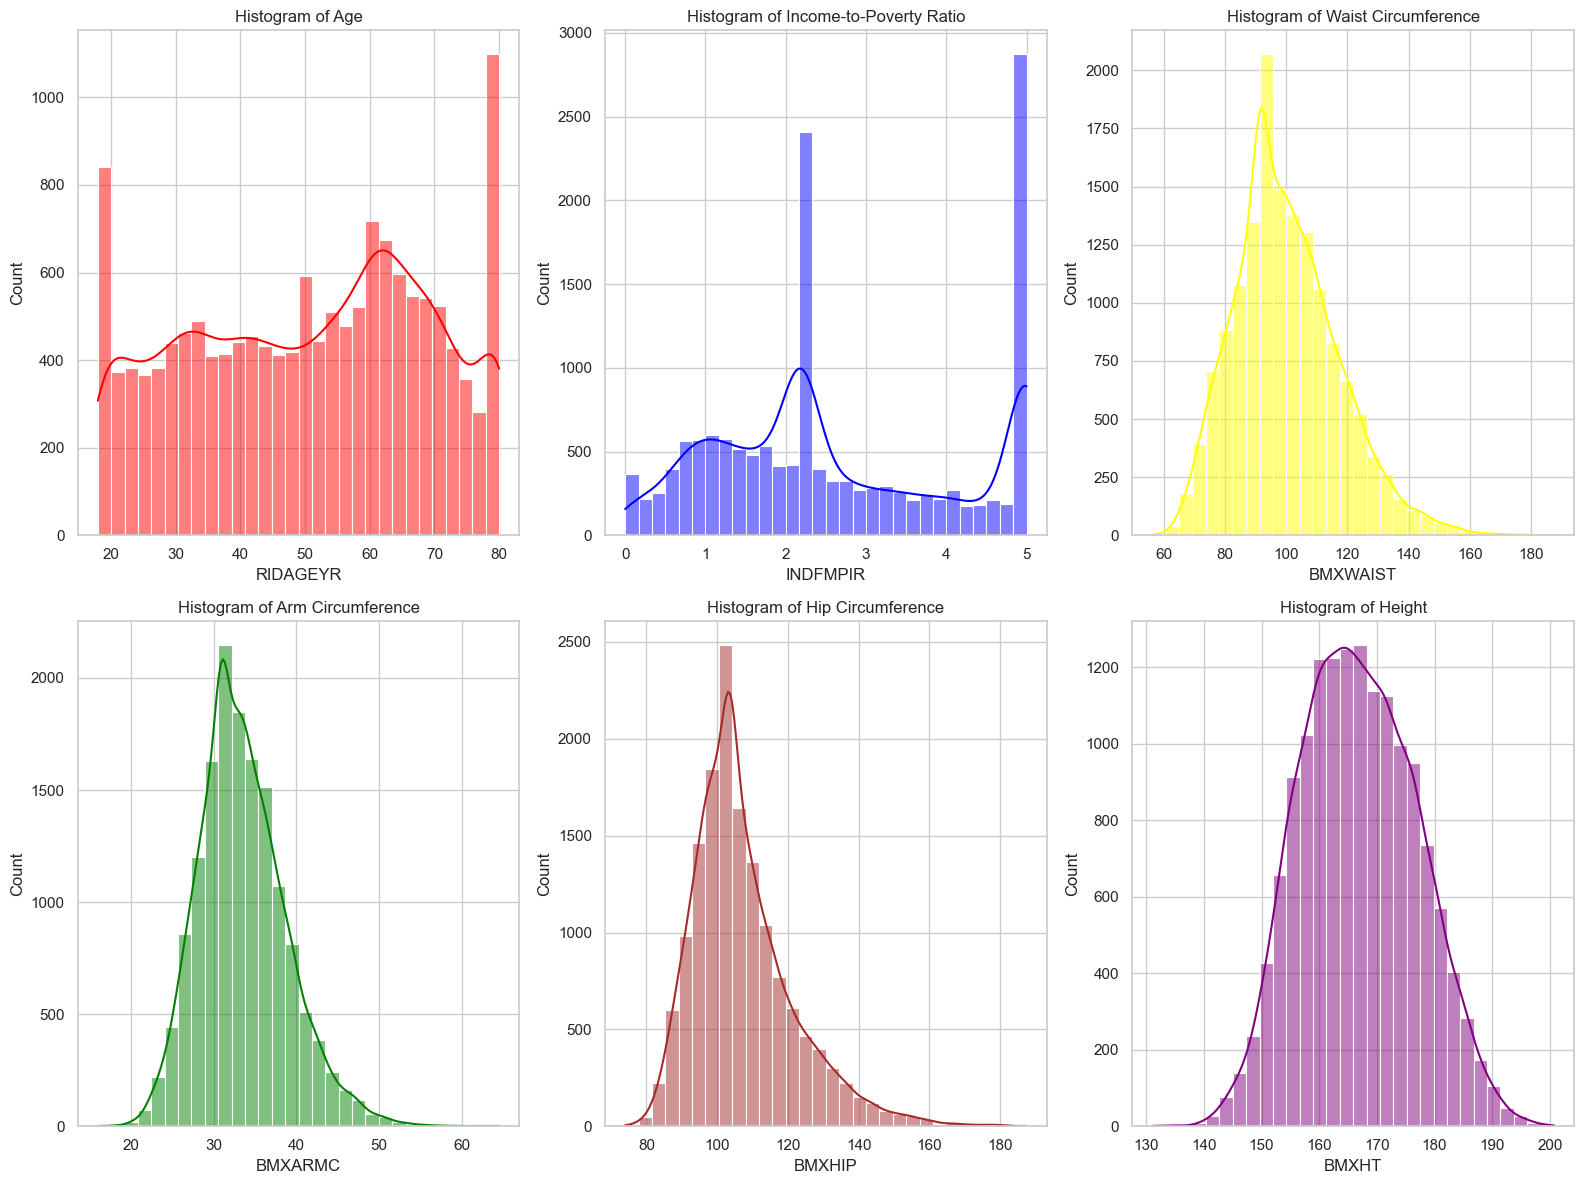

In [2]:
sns.set(style="whitegrid")
plt.figure(figsize=(16, 12))

# Plot 1: Age
plt.subplot(2, 3, 1)
sns.histplot(df['RIDAGEYR'], color='red', kde=True, bins=30)
plt.title("Histogram of Age")

# Plot 2: Income-to-poverty ratio
plt.subplot(2, 3, 2)
sns.histplot(df['INDFMPIR'], color='blue', kde=True, bins=30)
plt.title("Histogram of Income-to-Poverty Ratio")

# Plot 3: Waist circumference
plt.subplot(2, 3, 3)
sns.histplot(df['BMXWAIST'], color='yellow', kde=True, bins=30)
plt.title("Histogram of Waist Circumference")

# Plot 4: Arm circumference
plt.subplot(2, 3, 4)
sns.histplot(df['BMXARMC'], color='green', kde=True, bins=30)
plt.title("Histogram of Arm Circumference")

# Plot 5: Hip circumference
plt.subplot(2, 3, 5)
sns.histplot(df['BMXHIP'], color='brown', kde=True, bins=30)
plt.title("Histogram of Hip Circumference")

# Plot 6: Height
plt.subplot(2, 3, 6)
sns.histplot(df['BMXHT'], color='purple', kde=True, bins=30)
plt.title("Histogram of Height")

plt.tight_layout()
plt.savefig("Continuous_variables.png")

### The histograms show that all continuous variables follow expected adult population patterns. Age is broadly distributed across adulthood, income-to-poverty ratio is right‑skewed, and body measurements (waist, arm, hip, height) show normal‑like distributions with natural variation. No unusual shapes or extreme irregularities appear in these variables.

### 2.2 Categorical Variables

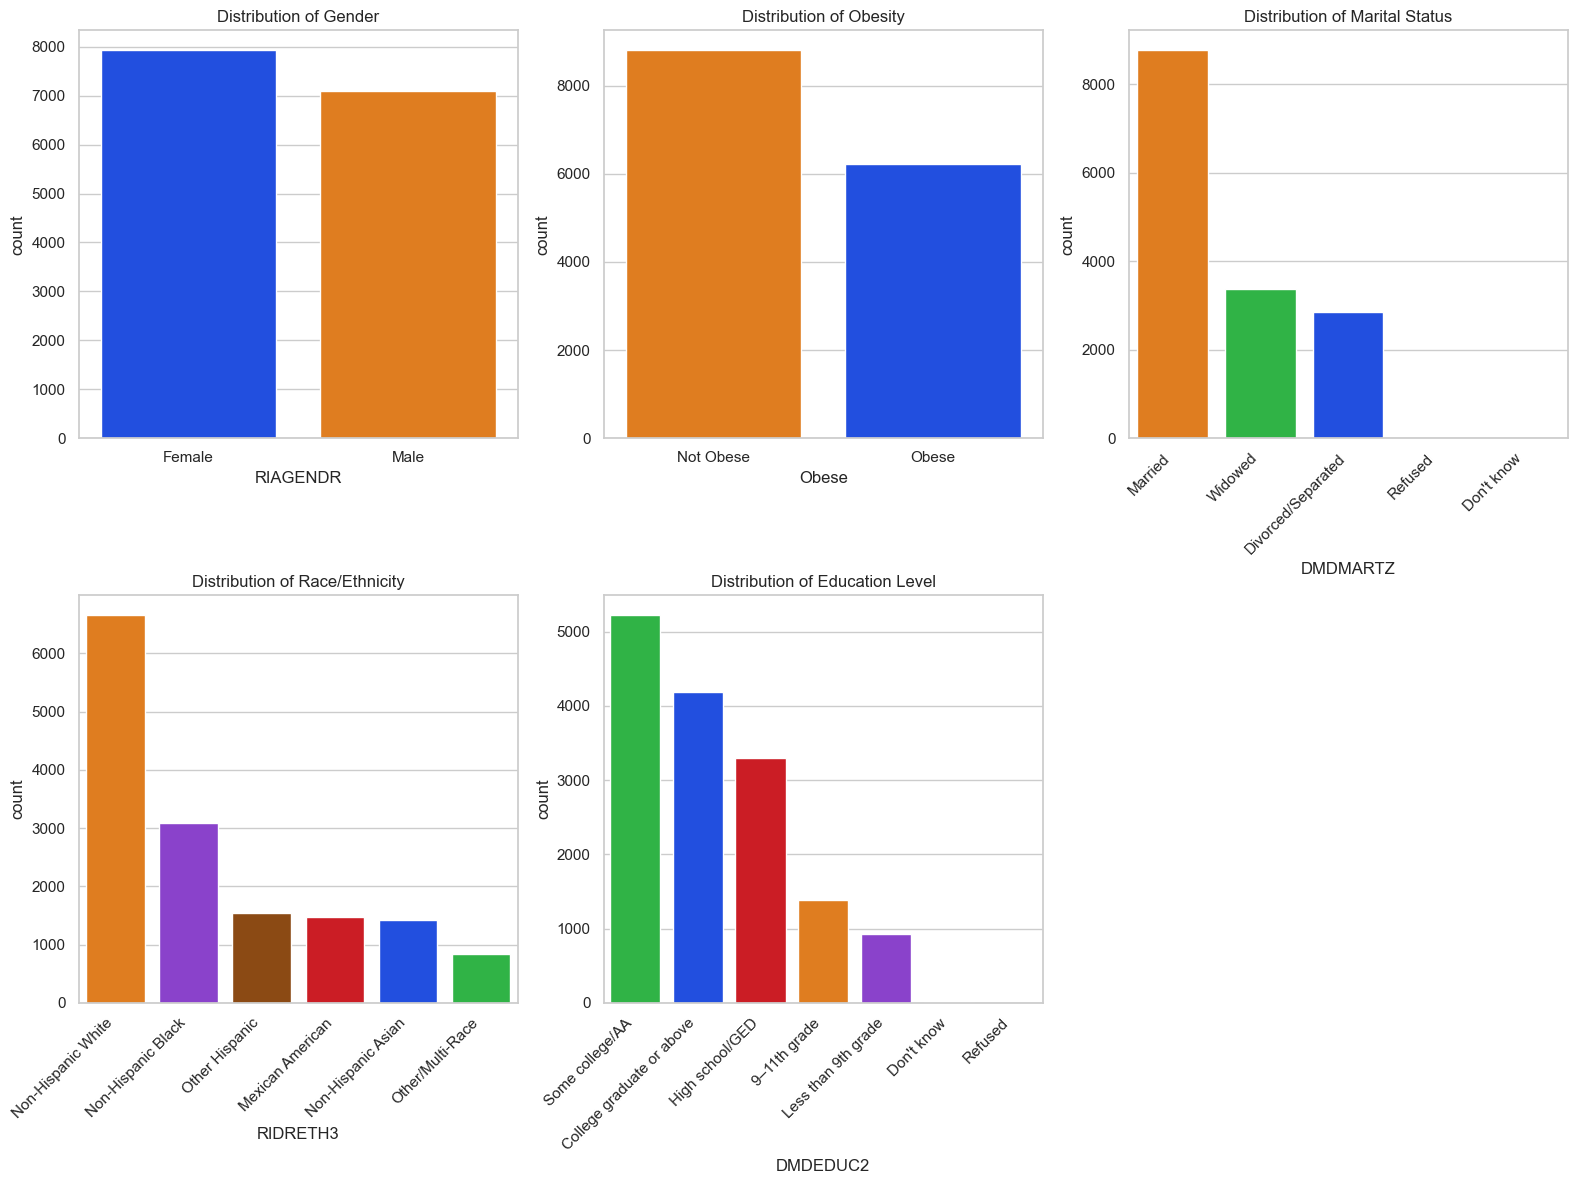

In [3]:
sns.set(style="whitegrid")
plt.figure(figsize=(16, 12))

# Gender
plt.subplot(2, 3, 1)
gender_labels = {1: 'Male', 2: 'Female'}
sns.countplot(data=df, x=df['RIAGENDR'].map(gender_labels),
              hue=df['RIAGENDR'].map(gender_labels), palette='bright', legend=False)
plt.title("Distribution of Gender")

# Obesity
plt.subplot(2, 3, 2)
obese_labels = {0: 'Not Obese', 1: 'Obese'}
obese_order = df['Obese'].map(obese_labels).value_counts().index
sns.countplot(data=df, x=df['Obese'].map(obese_labels), order=obese_order,
              hue=df['Obese'].map(obese_labels), palette='bright', legend=False)
plt.title("Distribution of Obesity")

# Marital status
plt.subplot(2, 3, 3)
marital_labels = {1: 'Married', 2: 'Widowed', 3: 'Divorced/Separated', 77: 'Refused', 99: "Don't know"}
marital_order = df['DMDMARTZ'].map(marital_labels).value_counts().index
sns.countplot(data=df, x=df['DMDMARTZ'].map(marital_labels), order=marital_order,
              hue=df['DMDMARTZ'].map(marital_labels), palette='bright', legend=False)
plt.title("Distribution of Marital Status")
plt.xticks(rotation=45, ha='right')

# Race/Ethnicity
plt.subplot(2, 3, 4)
race_labels = {1: 'Mexican American', 2: 'Other Hispanic', 3: 'Non-Hispanic White',
               4: 'Non-Hispanic Black', 6: 'Non-Hispanic Asian', 7: 'Other/Multi-Race'}
race_order = df['RIDRETH3'].map(race_labels).value_counts().index
sns.countplot(data=df, x=df['RIDRETH3'].map(race_labels), order=race_order,
              hue=df['RIDRETH3'].map(race_labels), palette='bright', legend=False)
plt.title("Distribution of Race/Ethnicity")
plt.xticks(rotation=45, ha='right')

# Education
plt.subplot(2, 3, 5)
edu_labels = {1: 'Less than 9th grade', 2: '9–11th grade', 3: 'High school/GED',
              4: 'Some college/AA', 5: 'College graduate or above', 7: 'Refused', 9: "Don't know"}
edu_order = df['DMDEDUC2'].map(edu_labels).value_counts().index
sns.countplot(data=df, x=df['DMDEDUC2'].map(edu_labels), order=edu_order,
              hue=df['DMDEDUC2'].map(edu_labels), palette='bright', legend=False)
plt.title("Distribution of Education Level")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig("Categorical_variables.png")
plt.show()

## 3. Bivariate Visualizations

### 3.1 Stacked Bar Charts (Categorical vs Obesity)

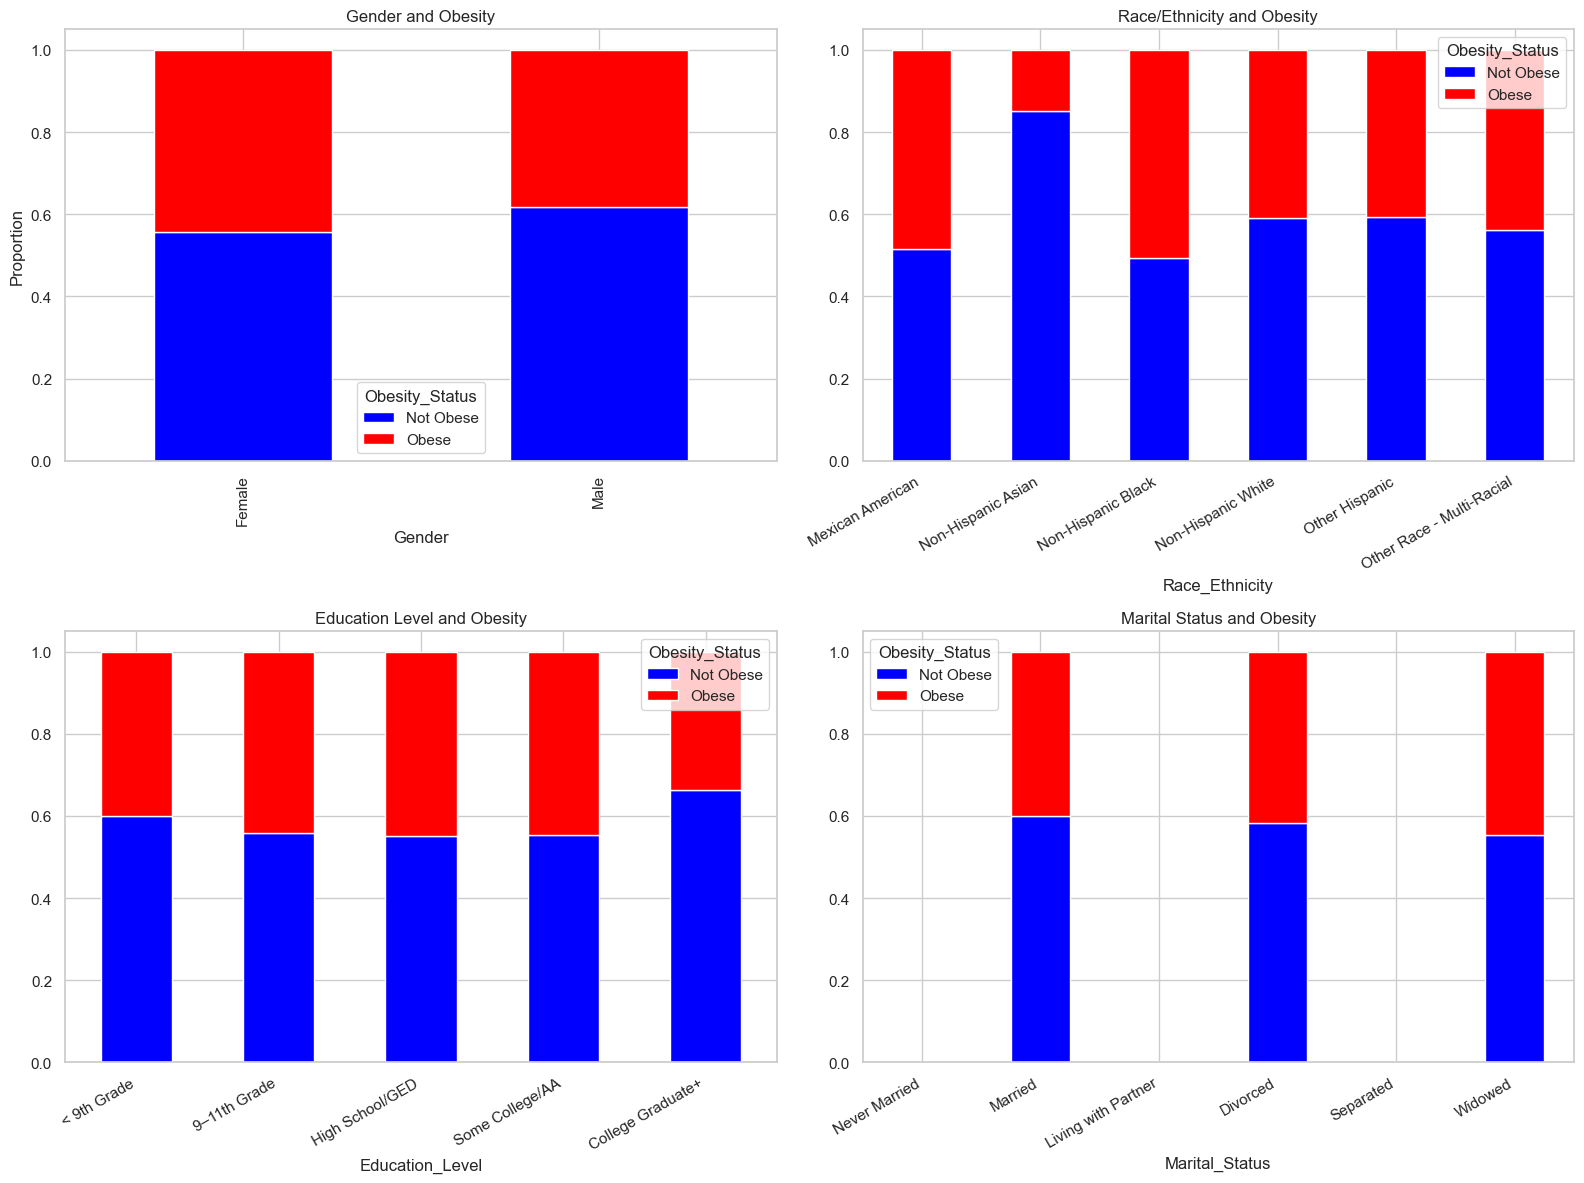

In [4]:
# Prepare labeled variables
df['Gender'] = df['RIAGENDR'].replace({1: 'Male', 2: 'Female'})
df['Obesity_Status'] = df['Obese'].replace({0: 'Not Obese', 1: 'Obese'})
df['Race_Ethnicity'] = df['RIDRETH3'].replace({1: 'Mexican American', 2: 'Other Hispanic',
                                               3: 'Non-Hispanic White', 4: 'Non-Hispanic Black',
                                               6: 'Non-Hispanic Asian', 7: 'Other Race - Multi-Racial'})
df['Education_Level'] = df['DMDEDUC2'].replace({1: '< 9th Grade', 2: '9–11th Grade',
                                                3: 'High School/GED', 4: 'Some College/AA',
                                                5: 'College Graduate+'})
df['Marital_Status'] = df['DMDMARTZ'].replace({1: 'Married', 2: 'Widowed', 3: 'Divorced',
                                               4: 'Separated', 5: 'Never Married',
                                               6: 'Living with Partner'})

colors = ["blue", "red"]

sns.set(style="whitegrid")
plt.figure(figsize=(16, 12))

# Gender
crosstab_G = pd.crosstab(df['Gender'], df['Obesity_Status'], normalize='index')
plt.subplot(2, 2, 1)
crosstab_G[['Not Obese', 'Obese']].plot(kind='bar', stacked=True, color=colors, ax=plt.gca())
plt.title('Gender and Obesity')
plt.ylabel('Proportion')

# Race/Ethnicity
crosstab_R = pd.crosstab(df['Race_Ethnicity'], df['Obesity_Status'], normalize='index')
plt.subplot(2, 2, 2)
crosstab_R[['Not Obese', 'Obese']].plot(kind='bar', stacked=True, color=colors, ax=plt.gca())
plt.title('Race/Ethnicity and Obesity')
plt.xticks(rotation=30, ha='right')

# Education
edu_order = ['< 9th Grade', '9–11th Grade', 'High School/GED', 'Some College/AA', 'College Graduate+']
crosstab_E = pd.crosstab(df['Education_Level'], df['Obesity_Status'], normalize='index').reindex(edu_order)
plt.subplot(2, 2, 3)
crosstab_E[['Not Obese', 'Obese']].plot(kind='bar', stacked=True, color=colors, ax=plt.gca())
plt.title('Education Level and Obesity')
plt.xticks(rotation=30, ha='right')

# Marital Status
marital_order = ['Never Married', 'Married', 'Living with Partner', 'Divorced', 'Separated', 'Widowed']
crosstab_M = pd.crosstab(df['Marital_Status'], df['Obesity_Status'], normalize='index').reindex(marital_order)
plt.subplot(2, 2, 4)
crosstab_M[['Not Obese', 'Obese']].plot(kind='bar', stacked=True, color=colors, ax=plt.gca())
plt.title('Marital Status and Obesity')
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig("Bivariate_stacked_bar_charts.png")
plt.show()

### 3.2 Boxplots (Continuous vs Obesity)

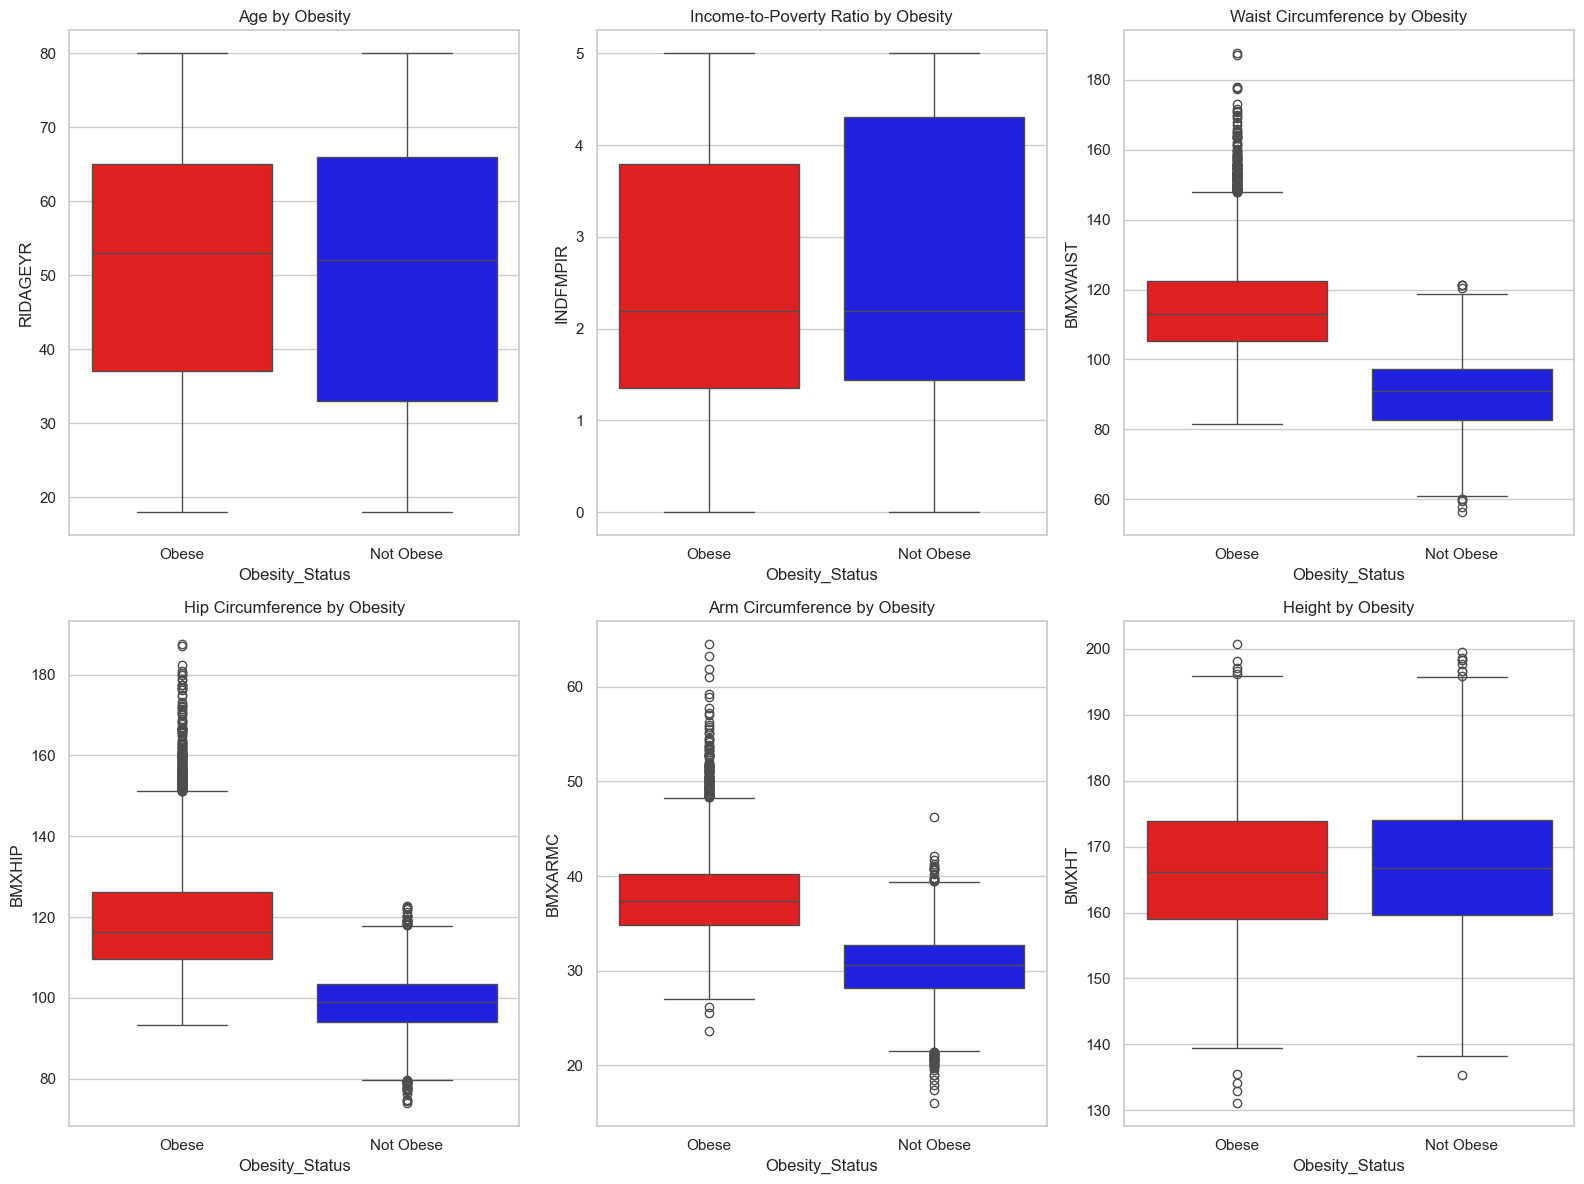

In [7]:
sns.set(style="whitegrid")
plt.figure(figsize=(16, 12))

df['Obesity_Status'] = df['Obese'].replace({0: 'Not Obese', 1: 'Obese'})

# Age
plt.subplot(2, 3, 1)
sns.boxplot(data=df, x='Obesity_Status', y='RIDAGEYR', hue='Obesity_Status',
            palette={'Not Obese': 'blue', 'Obese': 'red'}, legend=False)
plt.title('Age by Obesity')

# Income
plt.subplot(2, 3, 2)
sns.boxplot(data=df, x='Obesity_Status', y='INDFMPIR', hue='Obesity_Status',
            palette={'Not Obese': 'blue', 'Obese': 'red'}, legend=False)
plt.title('Income-to-Poverty Ratio by Obesity')

# Waist
plt.subplot(2, 3, 3)
sns.boxplot(data=df, x='Obesity_Status', y='BMXWAIST', hue='Obesity_Status',
            palette={'Not Obese': 'blue', 'Obese': 'red'}, legend=False)
plt.title('Waist Circumference by Obesity')

# Hip
plt.subplot(2, 3, 4)
sns.boxplot(data=df, x='Obesity_Status', y='BMXHIP', hue='Obesity_Status',
            palette={'Not Obese': 'blue', 'Obese': 'red'}, legend=False)
plt.title('Hip Circumference by Obesity')

# Arm
plt.subplot(2, 3, 5)
sns.boxplot(data=df, x='Obesity_Status', y='BMXARMC', hue='Obesity_Status',
            palette={'Not Obese': 'blue', 'Obese': 'red'}, legend=False)
plt.title('Arm Circumference by Obesity')

# Height
plt.subplot(2, 3, 6)
sns.boxplot(data=df, x='Obesity_Status', y='BMXHT', hue='Obesity_Status',
            palette={'Not Obese': 'blue', 'Obese': 'red'}, legend=False)
plt.title('Height by Obesity')

plt.tight_layout()
plt.savefig("Bivariate_Boxplots.png")
plt.show()

## 4. Notebook Summary

### This notebook visualized key patterns in the NHANES dataset by:

### - Exploring distributions of continuous and categorical variables

### - Comparing obesity across demographic groups

### - Examining how body measurements differ between obese and non‑obese adults

### These visual insights support the next step: logistic regression modeling to quantify the relationships.